## Quality control

this is our quality control document. we want to invetigate: 

* Apply some sort of missingness filter
Filter out ASVs that are not present in at least 5 samples
For 16S, also usually need at least 60 counts as well since we have count data
How many taxa are filtered out after doing this? If we combine the ASV labels with the taxonomic table, do you notice anything? 

* Filter out possible contaminants 
Human DNA could fall in during sample prep - need a list of possible contaminants (like homo sapiens) and then remove from further analysis.
How many taxa are possible contaminants?  How many samples have contaminants? 

* Convert to relative abundance data 
Instead of counts from 0 to 105k, we can convert these to percentages per sample
Need to think about how different taxonomic levels relate to relative abundances 


In [2]:
import pandas as pd 
import sklearn
from statsmodels.stats.multitest import multipletests

In [3]:
## read in my data.
asv_dat = pd.read_csv("../data/zebrafish_otu.tsv", sep = "\t")
asv_dat.head()

,ASV313,ASV099,ASV435,ASV102,ASV507,ASV431,ASV285,ASV097,ASV603,ASV141,...,ASV224,ASV519,ASV375,ASV433,ASV494,ASV239,ASV555,ASV575,ASV222,ASV340
BaP_0001,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0005,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
## taxa data
## read in the second file 
taxa_dat = pd.read_csv("../data/zebrafish_taxonomy.tsv", sep = "\t")
taxa_dat.head()

,Kingdom,Phylum,Class,Order,Family,Genus
ASV313,Bacteria,Firmicutes,Clostridia,Clostridia_or,Gracilibacteraceae,Lutispora
ASV099,Bacteria,Firmicutes,Bacilli,Lactobacillales,Leuconostocaceae,Weissella
ASV435,Bacteria,Firmicutes,Bacilli,Lactobacillales,Leuconostocaceae,Leuconostoc
ASV102,Bacteria,Firmicutes,Bacilli,Lactobacillales,Leuconostocaceae,Leuconostoc
ASV507,Bacteria,Firmicutes,Bacilli,Lactobacillales,Leuconostocaceae,Leuconostoc


## Missingness Filter
### AKA controlling for NAs

Zero values from the ASV table does not really mean that the taxa isn't present, just that we didn't count it. 

We want to reduce the zeroes in the dataset to try to have enough statistical power to actually use whats remaining. 

In [5]:
## first we just describe how many NAs there are in total 
asv_dat.head()
## count zeroes per row or per columns
## rows = individual samples; how many taxa we can detect in the study but that we don't detect in one sample
## columns = individual ASVs; how many samples that taxa is present in.

## how many taxa are present in at least five samples? 
## count the number of zeroes and nonzero values in each column (as two separate steps)
## filter the data by column sum >= 5

,ASV313,ASV099,ASV435,ASV102,ASV507,ASV431,ASV285,ASV097,ASV603,ASV141,...,ASV224,ASV519,ASV375,ASV433,ASV494,ASV239,ASV555,ASV575,ASV222,ASV340
BaP_0001,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0005,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
### now we know cell values with a value below 60 are probably low quality so we should change those to zero! 
# define threshold
count_threshold = 40 ## number of counts we consider permissible, allows us to test different options
## definitely don't go below 20, field standard is more around 30 
asv_dat.where(asv_dat >= count_threshold)
## let's us get a peak, seems right bc its mostly zeroes


,ASV313,ASV099,ASV435,ASV102,ASV507,ASV431,ASV285,ASV097,ASV603,ASV141,...,ASV224,ASV519,ASV375,ASV433,ASV494,ASV239,ASV555,ASV575,ASV222,ASV340
BaP_0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BaP_0002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BaP_0003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BaP_0004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BaP_0005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BaP_1112_140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BaP_1113_141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BaP_1114_142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BaP_1115_143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
## .mask follow if, then logic
## if condition is met, do something. otherwise, use NA or the probided value
asv_dat.mask(asv_dat < count_threshold) 


,ASV313,ASV099,ASV435,ASV102,ASV507,ASV431,ASV285,ASV097,ASV603,ASV141,...,ASV224,ASV519,ASV375,ASV433,ASV494,ASV239,ASV555,ASV575,ASV222,ASV340
BaP_0001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BaP_0002,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BaP_0003,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BaP_0004,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BaP_0005,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
BaP_1112_140,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BaP_1113_141,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BaP_1114_142,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BaP_1115_143,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
## what if we want the NA values replaced with zero?
dat_proc = asv_dat.mask(asv_dat < count_threshold, 0)

dat_proc.head()

,ASV313,ASV099,ASV435,ASV102,ASV507,ASV431,ASV285,ASV097,ASV603,ASV141,...,ASV224,ASV519,ASV375,ASV433,ASV494,ASV239,ASV555,ASV575,ASV222,ASV340
BaP_0001,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0002,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0003,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0004,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0005,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
## QUALITY CONTROL CHECK
## remove columns that are only zeroes
dat_proc = dat_proc.loc[:, (dat_proc != 0).any(axis=0)]
## check to make sure everything isn't all zeroes! 
#dat_proc['ASV047'].value_counts()
dat_proc.shape # rows, columns


(421, 76)

In [10]:
## removing ASVs (columns) detected in fewer than 5 samples
## mirror of in class example 
col_sums_threshold = dat_proc.eq(0).sum() > 416
#col_sums_threshold[:4] ## ASV 313 true, ASV099 false

## next: filter by number of counts
dat_filt = dat_proc.loc[:, ~col_sums_threshold]
dat_filt.head() ## only columns now where ASV is present in at least 5 samples 

,ASV012,ASV006,ASV001,ASV025,ASV041,ASV016,ASV021,ASV026,ASV034,ASV015,...,ASV020,ASV035,ASV032,ASV030,ASV019,ASV018,ASV029,ASV023,ASV027,ASV024
BaP_0001,0,514,1474,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0002,0,365,2495,0,0,0,0,0,0,92,...,0,0,0,0,0,0,0,0,0,0
BaP_0003,49,3875,3429,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0004,67,695,1562,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0005,115,1686,5315,52,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
dat_filt.shape

(421, 33)

What do you notice about our data frame after QC? 

Where do you think we might "relax" our QC standards to allow more of the data to make it through QC for analysis?

In [12]:
## relative abundance 
taxa_dat.head()
## which level might we care about the most? let's just say Class for now

,Kingdom,Phylum,Class,Order,Family,Genus
ASV313,Bacteria,Firmicutes,Clostridia,Clostridia_or,Gracilibacteraceae,Lutispora
ASV099,Bacteria,Firmicutes,Bacilli,Lactobacillales,Leuconostocaceae,Weissella
ASV435,Bacteria,Firmicutes,Bacilli,Lactobacillales,Leuconostocaceae,Leuconostoc
ASV102,Bacteria,Firmicutes,Bacilli,Lactobacillales,Leuconostocaceae,Leuconostoc
ASV507,Bacteria,Firmicutes,Bacilli,Lactobacillales,Leuconostocaceae,Leuconostoc


In [13]:
class_dat = taxa_dat.loc[~taxa_dat['Family'].isna()] ## because of weird ~ use, no need to specify :, for all rows
class_dat.head() ## bow faimly level!!

,Kingdom,Phylum,Class,Order,Family,Genus
ASV313,Bacteria,Firmicutes,Clostridia,Clostridia_or,Gracilibacteraceae,Lutispora
ASV099,Bacteria,Firmicutes,Bacilli,Lactobacillales,Leuconostocaceae,Weissella
ASV435,Bacteria,Firmicutes,Bacilli,Lactobacillales,Leuconostocaceae,Leuconostoc
ASV102,Bacteria,Firmicutes,Bacilli,Lactobacillales,Leuconostocaceae,Leuconostoc
ASV507,Bacteria,Firmicutes,Bacilli,Lactobacillales,Leuconostocaceae,Leuconostoc


In [14]:
## now we want to subset our dataframe after qc, dat_proc
## so select only ASVs with class level info 
## we see the asv label is the index of class_Dat, and the col name of dat_proc
shared_asvs = dat_filt.columns.intersection(class_dat.index).to_list()
shared_asvs

['ASV012',
 'ASV006',
 'ASV001',
 'ASV025',
 'ASV041',
 'ASV016',
 'ASV021',
 'ASV026',
 'ASV034',
 'ASV015',
 'ASV009',
 'ASV003',
 'ASV010',
 'ASV005',
 'ASV007',
 'ASV013',
 'ASV014',
 'ASV004',
 'ASV011',
 'ASV022',
 'ASV002',
 'ASV017',
 'ASV008',
 'ASV020',
 'ASV035',
 'ASV032',
 'ASV030',
 'ASV019',
 'ASV018',
 'ASV029',
 'ASV023',
 'ASV027',
 'ASV024']

In [15]:
dat_subset = dat_filt[dat_filt.columns.intersection(shared_asvs)]
dat_subset.head()

,ASV012,ASV006,ASV001,ASV025,ASV041,ASV016,ASV021,ASV026,ASV034,ASV015,...,ASV020,ASV035,ASV032,ASV030,ASV019,ASV018,ASV029,ASV023,ASV027,ASV024
BaP_0001,0,514,1474,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0002,0,365,2495,0,0,0,0,0,0,92,...,0,0,0,0,0,0,0,0,0,0
BaP_0003,49,3875,3429,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0004,67,695,1562,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0005,115,1686,5315,52,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [16]:
## now we also want to see those taxa! 
class_dat.loc[class_dat.index.isin(shared_asvs),:]

,Kingdom,Phylum,Class,Order,Family,Genus
ASV012,Bacteria,Firmicutes,Bacilli,Erysipelotrichales,Erysipelotrichaceae,ZOR0006
ASV006,Bacteria,Firmicutes,Bacilli,Erysipelotrichales,Erysipelotrichaceae,ZOR0006
ASV001,Bacteria,Fusobacteriota,Fusobacteriia,Fusobacteriales,Fusobacteriaceae,Cetobacterium
ASV025,Bacteria,Firmicutes,Clostridia,Peptostreptococcales-Tissierellales,Peptostreptococcaceae,Paraclostridium
ASV041,Bacteria,Proteobacteria,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas
ASV016,Bacteria,Proteobacteria,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas
ASV021,Bacteria,Proteobacteria,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas
ASV026,Bacteria,Proteobacteria,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas
ASV034,Bacteria,Proteobacteria,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas
ASV015,Bacteria,Proteobacteria,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas


In [17]:
print(f"After QC we see there are {dat_subset.shape[0] } samples and {dat_subset.shape[-1]} ASVs that pass our filters.\n Our count threshold is {count_threshold}.")

After QC we see there are 421 samples and 33 ASVs that pass our filters.
 Our count threshold is 40.


What do we notice about this list? ANything interesting stand out here? 

In [18]:
## PICK A taxonomic level to subset the data
## sum the counts for the samples for the ASVs from the same level category. 

## create index for class_Dat as class
class_dat['ASV'] = class_dat.index
#class_dat.set_index("Class")
class_dat.head()

,Kingdom,Phylum,Class,Order,Family,Genus,ASV
ASV313,Bacteria,Firmicutes,Clostridia,Clostridia_or,Gracilibacteraceae,Lutispora,ASV313
ASV099,Bacteria,Firmicutes,Bacilli,Lactobacillales,Leuconostocaceae,Weissella,ASV099
ASV435,Bacteria,Firmicutes,Bacilli,Lactobacillales,Leuconostocaceae,Leuconostoc,ASV435
ASV102,Bacteria,Firmicutes,Bacilli,Lactobacillales,Leuconostocaceae,Leuconostoc,ASV102
ASV507,Bacteria,Firmicutes,Bacilli,Lactobacillales,Leuconostocaceae,Leuconostoc,ASV507


In [19]:
dat_subset.head()

,ASV012,ASV006,ASV001,ASV025,ASV041,ASV016,ASV021,ASV026,ASV034,ASV015,...,ASV020,ASV035,ASV032,ASV030,ASV019,ASV018,ASV029,ASV023,ASV027,ASV024
BaP_0001,0,514,1474,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0002,0,365,2495,0,0,0,0,0,0,92,...,0,0,0,0,0,0,0,0,0,0
BaP_0003,49,3875,3429,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0004,67,695,1562,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0005,115,1686,5315,52,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [20]:
merged_dat = pd.merge(class_dat, dat_subset.T, left_index =True, right_index = True)
merged_dat.head()

,Kingdom,Phylum,Class,Order,Family,Genus,ASV,BaP_0001,BaP_0002,BaP_0003,...,BaP_1107_135,BaP_1108_136,BaP_1109_137,BaP_1110_138,BaP_1111_139,BaP_1112_140,BaP_1113_141,BaP_1114_142,BaP_1115_143,BaP_1116_144
ASV012,Bacteria,Firmicutes,Bacilli,Erysipelotrichales,Erysipelotrichaceae,ZOR0006,ASV012,0,0,49,...,51,0,0,49,130,0,107,0,0,0
ASV006,Bacteria,Firmicutes,Bacilli,Erysipelotrichales,Erysipelotrichaceae,ZOR0006,ASV006,514,365,3875,...,960,157,977,341,957,0,1889,291,500,1192
ASV001,Bacteria,Fusobacteriota,Fusobacteriia,Fusobacteriales,Fusobacteriaceae,Cetobacterium,ASV001,1474,2495,3429,...,6733,233,4881,4930,6936,7281,4305,6568,1177,416
ASV025,Bacteria,Firmicutes,Clostridia,Peptostreptococcales-Tissierellales,Peptostreptococcaceae,Paraclostridium,ASV025,0,0,0,...,0,0,0,0,0,0,0,0,0,0
ASV041,Bacteria,Proteobacteria,Gammaproteobacteria,Pseudomonadales,Pseudomonadaceae,Pseudomonas,ASV041,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
merged_dat.shape

(33, 428)

## Alpha Diversity 

our reference is this: https://colab.research.google.com/github/zaneveld/full_spectrum_bioinformatics/blob/master/content/07_tabular_omics_data/calculating_alpha_diversity.ipynb#scrollTo=wH69PxZmxi8T 

Alpha diversity tells us how ecologically "rich" a sample is (how many species) and ecological "evenness" (abundance balance). The tutorial had a good example of this. 

In [22]:
def get_observed_species(count_list):
    """Return the number of species with positive counts
    
    count_list -- a list of ints representing how many times each species was
    seen in an sample
    """
    observed_species = 0
    
    for i,current_count in enumerate(count_list):
        current_count = int(current_count)
        if current_count > 0:
            observed_species +=1
    
        elif current_count < 0:
            raise ValueError(f"Only positive species counts are allowed but {current_count} at position {i} is negative.")
    
    return observed_species
        

In [23]:
def calc_alpha_diversity(df,metric=get_observed_species):
    """Return a list of alpha diveristy values given a dataframe with samples on columns
    
    df -- a pandas dataframe with samples on the columns and microbe ids on the rows
    metric -- a python function that takes a column of species abundances as input and returns a vector
    of diversity data 
    """


    column_names = list(df.columns)

    alpha_diversity = {}
    for column in column_names:
    
        current_data = list(df[column])
        current_diversity = metric(current_data)
        alpha_diversity[column] = current_diversity
    
    alpha_diversity = pd.DataFrame.from_dict(data=alpha_diversity, orient='index', columns=['alpha_diversity'])
    return alpha_diversity



In [24]:
## we can see we need samples as columns and microbes as rows, so we want to transpose our DF

sub_t = dat_subset.T

In [25]:
## apply the function
calc_alpha_diversity(sub_t)

,alpha_diversity
BaP_0001,10
BaP_0002,10
BaP_0003,9
BaP_0004,9
BaP_0005,10
...,...
BaP_1112_140,8
BaP_1113_141,7
BaP_1114_142,12
BaP_1115_143,10


In [26]:
alpha_div_df = calc_alpha_diversity(sub_t)
alpha_div_df.to_csv("../results/alpha_div_results.csv", index_label = "#SampleID", header=["observed_features"], sep=",")

We would probably want to add in more information and subset the dataframe to match the experimental design. For example, is there a differences in alpha diversity within the same generation across experimental conditions? 

## Beta Diveristy

Beta diversity is different from alpha diversity because beta diversity is inherently a comparison, while an alpha diversity measure could be calculated for just one group. 

In the microbiome world, beta diversity is most often calculated with a bray-curtis distance metric. We will try to avoid the math, but basically, this is because we have many small values close to zero, and few very large values. This is because microbiomes tend to be made up of many members rather than dominated by one specific microbe. 

For this, we need to first think about your research question and connect the meta data for group comparison. 

In [27]:
## live demo, first
## can students read in the appropriate data file? 
## can they connect the sample name from dat_proc to the data? 
## can the subset dat_proc by the meta data column that interests them? 

In [28]:
## read in the interesting data
study_dat = pd.read_csv("../data/zebrafish_sample.tsv", sep = "\t")
study_dat.head()

,SampleID,Barcode,Treatments,Generation,Sex,Morph,Exposure,Fish,Tissue,RunID,RGSM,Read1File,Read2File
BaP_0001,BaP_0001,GTAAACGACTTG,AHR2Mo+BaP,F2,F,AHR2Mo,BaP,141,Fecal,s434,lane1-s434-index-GTAAACGACTTG-BaP_0001,/nfs2/hts/miseq/211220_M01498_0865_000000000-K...,/nfs2/hts/miseq/211220_M01498_0865_000000000-K...
BaP_0002,BaP_0002,TATACCGCTGCG,AHR2Mo+BaP,F2,F,AHR2Mo,BaP,135,Fecal,s428,lane1-s428-index-TATACCGCTGCG-BaP_0002,/nfs2/hts/miseq/211220_M01498_0865_000000000-K...,/nfs2/hts/miseq/211220_M01498_0865_000000000-K...
BaP_0003,BaP_0003,TTCGATGCCGCA,AHR2Mo+DMSO,F0,F,AHR2Mo,DMSO,93,Fecal,s097,lane1-s097-index-TTCGATGCCGCA-BaP_0003,/nfs2/hts/miseq/211220_M01498_0865_000000000-K...,/nfs2/hts/miseq/211220_M01498_0865_000000000-K...
BaP_0004,BaP_0004,TCGTTATTCAGT,AHR2Mo+DMSO,F0,F,AHR2Mo,DMSO,94,Fecal,s098,lane1-s098-index-TCGTTATTCAGT-BaP_0004,/nfs2/hts/miseq/211220_M01498_0865_000000000-K...,/nfs2/hts/miseq/211220_M01498_0865_000000000-K...
BaP_0005,BaP_0005,ACTCTGTAATTA,AHR2Mo+DMSO,F0,F,AHR2Mo,DMSO,95,Fecal,s099,lane1-s099-index-ACTCTGTAATTA-BaP_0005,/nfs2/hts/miseq/211220_M01498_0865_000000000-K...,/nfs2/hts/miseq/211220_M01498_0865_000000000-K...


In [29]:
minidat = study_dat[["SampleID", "Generation", "Treatments"]]
minidat.head()

,SampleID,Generation,Treatments
BaP_0001,BaP_0001,F2,AHR2Mo+BaP
BaP_0002,BaP_0002,F2,AHR2Mo+BaP
BaP_0003,BaP_0003,F0,AHR2Mo+DMSO
BaP_0004,BaP_0004,F0,AHR2Mo+DMSO
BaP_0005,BaP_0005,F0,AHR2Mo+DMSO


In [30]:

gen_dat = pd.merge(minidat, dat_filt, left_index = True, right_index = True)
gen_dat.head()

,SampleID,Generation,Treatments,ASV012,ASV006,ASV001,ASV025,ASV041,ASV016,ASV021,...,ASV020,ASV035,ASV032,ASV030,ASV019,ASV018,ASV029,ASV023,ASV027,ASV024
BaP_0001,BaP_0001,F2,AHR2Mo+BaP,0,514,1474,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0002,BaP_0002,F2,AHR2Mo+BaP,0,365,2495,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0003,BaP_0003,F0,AHR2Mo+DMSO,49,3875,3429,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0004,BaP_0004,F0,AHR2Mo+DMSO,67,695,1562,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0005,BaP_0005,F0,AHR2Mo+DMSO,115,1686,5315,52,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
## lets say we only want to look at baseline data 
baseline_gen = gen_dat.loc[ gen_dat['Generation'] == "F0"]
baseline_gen.head()

,SampleID,Generation,Treatments,ASV012,ASV006,ASV001,ASV025,ASV041,ASV016,ASV021,...,ASV020,ASV035,ASV032,ASV030,ASV019,ASV018,ASV029,ASV023,ASV027,ASV024
BaP_0003,BaP_0003,F0,AHR2Mo+DMSO,49,3875,3429,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0004,BaP_0004,F0,AHR2Mo+DMSO,67,695,1562,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0005,BaP_0005,F0,AHR2Mo+DMSO,115,1686,5315,52,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0006,BaP_0006,F0,AHR2Mo+DMSO,0,563,8569,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0007,BaP_0007,F0,AHR2Mo+DMSO,0,717,4081,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [33]:
## read in modules
from skbio.stats.distance import DistanceMatrix
from scipy.spatial.distance import pdist, squareform
import skbio.stats

In [34]:
## note the number of conditions
baseline_gen['Treatments'].value_counts()

Treatments
AHR2Mo+BaP     36
CoMo+DMSO      36
AHR2Mo+DMSO    35
CoMo+BaP       35
Name: count, dtype: int64

In [35]:
# create distance matrix object
## sub_transposed is the subset of the dataframe with just the microbiome data
count_dat = baseline_gen.drop(['SampleID', 'Generation', "Treatments"], axis = 1)
## grouping is the variable we are interested in!! 
grouping = baseline_gen['Treatments']


#make distance matrix
dist_square = squareform(pdist(count_dat, metric="braycurtis"))
ids = baseline_gen.index.astype(str).tolist() 
distmat = DistanceMatrix(dist_square, ids=ids)

In [36]:
grouping.index = distmat.ids

#run PERMANOVA (significance test after beta diversity)
result = skbio.stats.distance.permanova(distmat, grouping, permutations=999)
print(result)

method name               PERMANOVA
test statistic name        pseudo-F
sample size                     142
number of groups                  4
test statistic             4.578522
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object


Here we see that the unadjusted p value is 0.001, indicating that the bray-curtis beta diversity is significantly different between treatment conditions at baseline. However, there are many treatments to compare! How do we know which condition is significantly different from which? 

In [37]:
## set up code from Malena Voss
## running bash commands in jupyter notebook with !command
#!wget https://raw.githubusercontent.com/ivanp1994/PyPerMANOVA/main/PyPerMANOVA.py
#!sed -i 's/from scipy.stats.stats import _unequal_var_ttest_denom/from scipy.stats._stats_py import _unequal_var_ttest_denom/' ./PyPerMANOVA.py

In [38]:
%%bash
## alternative way to run bash in jupyter
#wget https://raw.githubusercontent.com/ivanp1994/PyPerMANOVA/main/PyPerMANOVA.py
#sed -i 's/from scipy.stats.stats import _unequal_var_ttest_denom/from scipy.stats._stats_py import _unequal_var_ttest_denom/' ./PyPerMANOVA.py

In [39]:
import sklearn 
from PyPerMANOVA import permutational_analysis
from statsmodels.stats.multitest import multipletests

In [40]:
#copy PyPerMANOVA Github, code from Malena Vos
permanova_result, posthoc_result = permutational_analysis(
    data=count_dat.T,
    mapping=grouping,
    norm="row",
    metric="braycurtis",
    permutations=999 ## students: define seed
)

# recalculate with FDR-BH instead of Bonferroni
_, fdr_pvals, _, _ = multipletests(posthoc_result['Pval'], method='fdr_bh')
posthoc_result['adj-pval-fdr'] = fdr_pvals

print(permanova_result)
print(posthoc_result[['A', 'B', 'Pval', 'bonf', 'adj-pval-fdr', 'eta-sqr', 'cohen-d']])

    Pval   eta-sqr        F
0  0.001  0.121815  6.38075
             A           B   Pval   bonf  adj-pval-fdr   eta-sqr   cohen-d
0  AHR2Mo+DMSO  AHR2Mo+BaP  0.001  0.006        0.0015  0.086860  0.620036
1  AHR2Mo+DMSO   CoMo+DMSO  0.001  0.006        0.0015  0.071205  0.557537
2  AHR2Mo+DMSO    CoMo+BaP  0.002  0.012        0.0024  0.060364  0.513718
3   AHR2Mo+BaP   CoMo+DMSO  0.001  0.006        0.0015  0.103818  0.680797
4   AHR2Mo+BaP    CoMo+BaP  0.001  0.006        0.0015  0.158366  0.869306
5    CoMo+DMSO    CoMo+BaP  0.371  2.226        0.3710  0.015321  0.249764


# Downstream Statistics

We have now calculated alpha & beta diversity, and conducted a statistical test to see which groups are significantly different from one another with the PyPermanova. 

from the paper:

"We then applied this question across generations by including sequence data from all generations in our models as well as analyzing F1 and F2 generations individually. We used two modeling approaches with these data: (1) the same modeling approach as in F0 fish applied to
each subsequent generation (F1 and F2), wherein BaP exposure, AHR2 morpholino, sex, and the interaction between each of these were independent variables and alpha- and beta diversity gut microbiome metrics were each the dependent variable"

regarding deeper bray-curtis analysis: 

"We wanted to visualize how beta diversity varied across the three generations within each treatment, so we created a Bray–Curtis based metric to evaluate this. We first calculated Bray–Curtis dissimilarity for the full dataset. Then, we calculated the difference in
dissimilarity between the F0 centroid all points in the F0 generation (as a baseline), F1, and F2. We then normalized to the “F0 centroid to F0 points” distance so that all distances for F1 and F2 were relative to F0, and F0 was on average zero. For example, the F0 metric was calculated as follows: distance from centroid F0 to each point in F0 divided by median distance from centroid F0 to each point in F0, minus 1. The calculation for F1 was distance from centroid F0 to each point in F1 divided by median distance from centroid F0 to each point in F0, minus 1. This represents, essentially, the dissimilarity in microbiomes between each F1 and F2 compared to F0. We performed this for each exposure/morpholino treatment individually. We use this measure to compare gut microbiome beta diversity trends across generations."

In [41]:
## first main finding: alpha  diversity (in the paper, species richness for treatment groups)
alpha_div_df.head()


,alpha_diversity
BaP_0001,10
BaP_0002,10
BaP_0003,9
BaP_0004,9
BaP_0005,10


In [42]:
## merge with mini meta data
alpha_dat = pd.merge(minidat, alpha_div_df, left_index = True, right_index = True)
alpha_dat.head()

,SampleID,Generation,Treatments,alpha_diversity
BaP_0001,BaP_0001,F2,AHR2Mo+BaP,10
BaP_0002,BaP_0002,F2,AHR2Mo+BaP,10
BaP_0003,BaP_0003,F0,AHR2Mo+DMSO,9
BaP_0004,BaP_0004,F0,AHR2Mo+DMSO,9
BaP_0005,BaP_0005,F0,AHR2Mo+DMSO,10


In [43]:
## create color palette
palette = {
    "AHR2Mo+BaP": "sandybrown",
    "AHR2Mo+DMSO": "moccasin",
    "CoMo+DMSO": "purple",
    "CoMo+BaP": "mediumpurple"
}


C:\Users\emily\AppData\Local\Temp\ipykernel_2716\1208467137.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


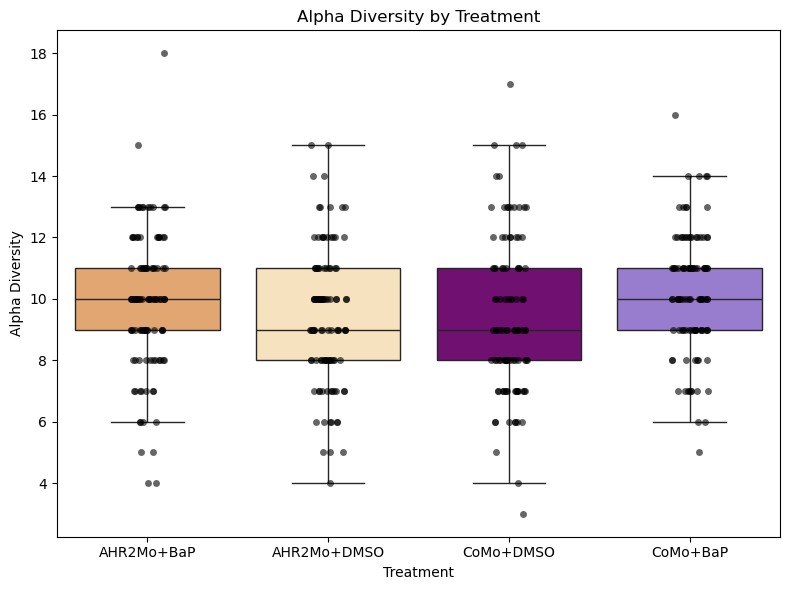

In [44]:
## plot alpha diversity by treatment
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.boxplot(
    data=alpha_dat,
    x="Treatments",
    y="alpha_diversity",
    palette=palette,
    showfliers=False  
)

sns.stripplot(
    data=alpha_dat,
    x="Treatments",
    y="alpha_diversity",
    color="black",
    alpha=0.6,
    jitter=True
)

plt.xlabel("Treatment")
plt.ylabel("Alpha Diversity")
plt.title("Alpha Diversity by Treatment")
plt.tight_layout()

plt.show()

This looks a bit different from their plot!! Do we have an idea why this is?

It is because we are probably using different measures of alpha diversity. They also split by sex in the original plot. Can you try to do that on your own? 

In [45]:
## generate the same plot as above, but this time, make the X axis sex of the fish
## hint: you will need a new minidat that has sex as a column included. 

### PCoA

We want to produce a PCoA to show the bray-curtis diversity. This is a slightly simpler statistic than the figure's plot, but the interpretation will be similar. 

Do you remember how we interpret PCoAs? What do they tell us? 

In [46]:
## 
print(distmat) ## data matrix 
print(grouping[:4]) ## ids of fish to treatment condition 

142x142 distance matrix
IDs:
'BaP_0003', 'BaP_0004', 'BaP_0005', 'BaP_0006', 'BaP_0007', 'BaP_0008', ...
Data:
[[0.         0.5800977  0.25102757 ... 0.80139946 0.48135508 0.54438946]
 [0.5800977  0.         0.60446217 ... 0.86878789 0.66380269 0.79779281]
 [0.25102757 0.60446217 0.         ... 0.77256318 0.27018462 0.31828305]
 ...
 [0.80139946 0.86878789 0.77256318 ... 0.         0.73384973 0.57748675]
 [0.48135508 0.66380269 0.27018462 ... 0.73384973 0.         0.37164867]
 [0.54438946 0.79779281 0.31828305 ... 0.57748675 0.37164867 0.        ]]
BaP_0003    AHR2Mo+DMSO
BaP_0004    AHR2Mo+DMSO
BaP_0005    AHR2Mo+DMSO
BaP_0006    AHR2Mo+DMSO
Name: Treatments, dtype: str


In [47]:
## first we need to compute the PCoA
from skbio.stats.ordination import pcoa
## using the distmat from earlier - already bray-curtis values in DistanceMatrix format for pcoa
pcoa_results = pcoa(distmat)

# Get first two axes for PC1 and PC2 for labels
coords = pcoa_results.samples.iloc[:, :2].copy()
coords.columns = ["PCoA1", "PCoA2"]

# merge with subset of  metadata
plot_df = coords.merge(
    minidat[["SampleID", "Treatments"]],
    left_index=True,
    right_on="SampleID"
)

plot_df.head()

c:\Users\emily\miniforge3\envs\daisy_env\Lib\site-packages\skbio\stats\ordination\_principal_coordinate_analysis.py:222: RuntimeWarning: EIGH: since no value for dimensions is specified, PCoA for all dimensions will be computed, which may result in long computation time if the original distance matrix is large.
  warn(
c:\Users\emily\miniforge3\envs\daisy_env\Lib\site-packages\skbio\stats\ordination\_principal_coordinate_analysis.py:359: RuntimeWarning: The result contains negative eigenvalues that are large in magnitude, which may suggest result inaccuracy. See Notes for details. The negative-most eigenvalue is -0.6781368130051708 whereas the largest positive one is 9.754567621700486.
  warn(


,PCoA1,PCoA2,SampleID,Treatments
BaP_0003,-0.265804,0.019326,BaP_0003,AHR2Mo+DMSO
BaP_0004,-0.104311,0.032638,BaP_0004,AHR2Mo+DMSO
BaP_0005,-0.347496,0.003746,BaP_0005,AHR2Mo+DMSO
BaP_0006,-0.429518,0.121670,BaP_0006,AHR2Mo+DMSO
BaP_0007,-0.201816,-0.211671,BaP_0007,AHR2Mo+DMSO


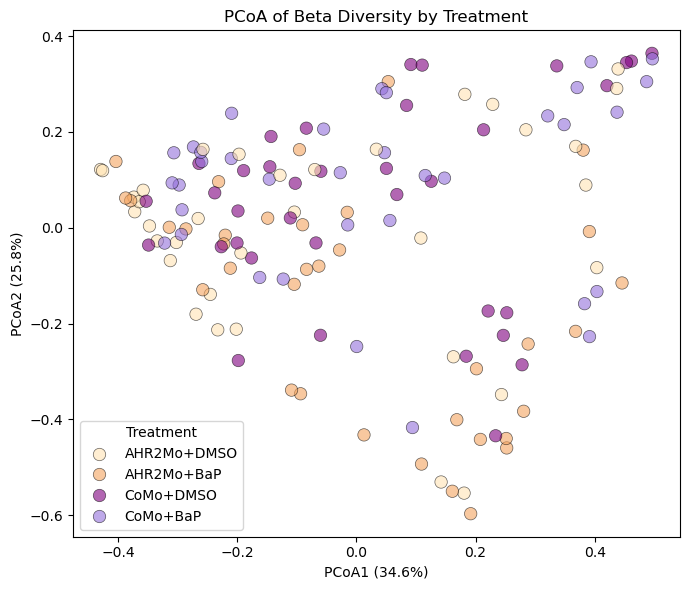

In [48]:
## plot
plt.figure(figsize=(7, 6))

sns.scatterplot(
    data=plot_df,
    x="PCoA1",
    y="PCoA2",
    hue="Treatments",
    palette=palette,
    s=80,
    alpha = 0.6,
    edgecolor="black",
    linewidth=0.5
)
plt.xlabel(f"PCoA1 ({pcoa_results.proportion_explained.iloc[0]*100:.1f}%)")
plt.ylabel(f"PCoA2 ({pcoa_results.proportion_explained.iloc[1]*100:.1f}%)")
plt.legend(title="Treatment")
plt.title("PCoA of Beta Diversity by Treatment")
plt.tight_layout()
plt.show()

What do we notice when we compare this PCoA to the dbRDA ordination in the manuscript figure? Why do we think these look different? Should we be worried? 

The figure in the manuscript has more information than what we have here. Can you tell what it is? 

In [49]:
## try to do the PCoA with sex integrated as well to match the figure in the manuscript
## hint: re-subset minidat with sex as a column, then make the shape of the points vary by sex 

# Differential Expression

## U-tests and Volcano Plots

we are using kruskal-wallis u test, could consider mann whitney u test

What i recommend to students:

* consider adjusting the QC values (like the threshold for the number of counts)

* consider adjusting the raw counts into relative abundance (to account for differences in sequncing depth )

* consider which two groups to compare (such as by making a new column sex + treatments)

* think about the minimum number of observations required per taxa per group for the kruskal test. can you adjust the defaults? should we apply a different type of u-test? 

In [50]:
## first, what will out group be?
baseline_gen['Treatments'].value_counts()

Treatments
AHR2Mo+BaP     36
CoMo+DMSO      36
AHR2Mo+DMSO    35
CoMo+BaP       35
Name: count, dtype: int64

In [56]:
## first set up the runs to be more automatted & seperate out the data' groups
group_col_name = "Treatments"
group1 = "CoMo+DMSO"
group2 = "AHR2Mo+DMSO"

kruskal_data = baseline_gen[baseline_gen[group_col_name].isin([group1, group2])]
kruskal_data.sort_index(inplace=True)
kruskal_data.head()

,SampleID,Generation,Treatments,ASV012,ASV006,ASV001,ASV025,ASV041,ASV016,ASV021,...,ASV020,ASV035,ASV032,ASV030,ASV019,ASV018,ASV029,ASV023,ASV027,ASV024
BaP_0003,BaP_0003,F0,AHR2Mo+DMSO,49,3875,3429,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0004,BaP_0004,F0,AHR2Mo+DMSO,67,695,1562,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0005,BaP_0005,F0,AHR2Mo+DMSO,115,1686,5315,52,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0006,BaP_0006,F0,AHR2Mo+DMSO,0,563,8569,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
BaP_0007,BaP_0007,F0,AHR2Mo+DMSO,0,717,4081,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [52]:
import scipy.stats as stats

In [57]:
##do kruskal test = extention on Mann Whitney U test 
##is for 3 or more independent groups
results = []
taxa_list = [col for col in baseline_gen.columns if col not in minidat] ## could also use count_dat object previously made!! 
taxa_list.sort()
for taxa in taxa_list:
    group1_taxadat = kruskal_data[kruskal_data[group_col_name] == str(group1)][taxa]
    group2_taxadat = kruskal_data[kruskal_data[group_col_name] == str(group2)][taxa]
    
    stat, p = stats.kruskal(group1_taxadat, group2_taxadat) ## what is the minimum requires obs by default? n = 3; up to 5
    results.append({'taxa': taxa, 'stat': stat, 'p_value': p})

kruskal_results = pd.DataFrame(results).sort_values('p_value')
# how many NaN p-values?
#print(kruskal_results['p_value'].isna().sum())
#we have NaNs which needs to be dropped before p value adjustment
kruskal_results = kruskal_results.dropna(subset=['p_value'])
print(f"Shape of results obj: {kruskal_results.shape}")

reject, p_adj, _, _ = multipletests(kruskal_results['p_value'], method='fdr_bh')
kruskal_results['p_adj'] = p_adj
kruskal_results['significant'] = reject

# significant hits only
print(f"Conducting U-test for {group1} and {group2} . . . ")
print(f"Total taxa tested: {len(kruskal_results)}")
print(f"Significant after FDR correction: {kruskal_results['significant'].sum()}")
print(f"Proportion significant: {kruskal_results['significant'].mean():.1%}")
kruskal_results[kruskal_results['significant']].sort_values('p_adj')

Shape of results obj: (28, 3)
Conducting U-test for CoMo+DMSO and AHR2Mo+DMSO . . . 
Total taxa tested: 28
Significant after FDR correction: 4
Proportion significant: 14.3%


c:\Users\emily\miniforge3\envs\daisy_env\Lib\site-packages\scipy\stats\_stats_py.py:8674: RuntimeWarning: invalid value encountered in scalar divide
  h /= ties
c:\Users\emily\miniforge3\envs\daisy_env\Lib\site-packages\scipy\stats\_stats_py.py:8674: RuntimeWarning: invalid value encountered in scalar divide
  h /= ties
c:\Users\emily\miniforge3\envs\daisy_env\Lib\site-packages\scipy\stats\_stats_py.py:8674: RuntimeWarning: invalid value encountered in scalar divide
  h /= ties
c:\Users\emily\miniforge3\envs\daisy_env\Lib\site-packages\scipy\stats\_stats_py.py:8674: RuntimeWarning: invalid value encountered in scalar divide
  h /= ties
c:\Users\emily\miniforge3\envs\daisy_env\Lib\site-packages\scipy\stats\_stats_py.py:8674: RuntimeWarning: invalid value encountered in scalar divide
  h /= ties


,taxa,stat,p_value,p_adj,significant
6,ASV007,15.985802,0.000064,0.001787,True
3,ASV004,11.568223,0.000671,0.009392,True
2,ASV003,8.429577,0.003692,0.034456,True
8,ASV009,7.246045,0.007106,0.049740,True


How would we interpret this result?

In [59]:
kruskal_results.head()

,taxa,stat,p_value,p_adj,significant
6,ASV007,15.985802,0.000064,0.001787,True
3,ASV004,11.568223,0.000671,0.009392,True
2,ASV003,8.429577,0.003692,0.034456,True
8,ASV009,7.246045,0.007106,0.049740,True
11,ASV012,6.747380,0.009389,0.052576,False


## Plotting following significant U-test

Volcano plots are how we represent significant taxa from differential expression analysis as it is easy to interpret, but we can only compare two groups at once. 

First, we want to calculate a mean value of the counts for the two groups we did the U-test for. Then, we want to plot that with the adjusted p value on the y axis. 


In [71]:
## first, we want to add a col to kruskal_results that will have the fold-change expression for group1 and group2
kruskal_data.head()
kruskal_results['fold_change'] = None 

for taxa in kruskal_results['taxa']:
    group1_taxadat_mean = kruskal_data[kruskal_data[group_col_name] == str(group1)][taxa].mean()
    group2_taxadat_mean = kruskal_data[kruskal_data[group_col_name] == str(group2)][taxa].mean()
    fold_change = round(group1_taxadat_mean / group2_taxadat_mean, 6)

    kruskal_results.loc[kruskal_results['taxa'] == taxa, 'fold_change'] = fold_change

kruskal_results['fold_change'] = pd.to_numeric(kruskal_results['fold_change'], errors='coerce')
kruskal_results.head() ## confirm it worked

,taxa,stat,p_value,p_adj,significant,fold_change
6,ASV007,15.985802,0.000064,0.001787,True,5.041553
3,ASV004,11.568223,0.000671,0.009392,True,0.071348
2,ASV003,8.429577,0.003692,0.034456,True,1.711756
8,ASV009,7.246045,0.007106,0.049740,True,1.720943
11,ASV012,6.747380,0.009389,0.052576,False,0.129749


In [69]:
import numpy as np
import matplotlib.pyplot as plt

In [74]:
def safe_log2(x):
    if pd.isna(x) or x <= 0:
        return 0
    return np.log2(x)

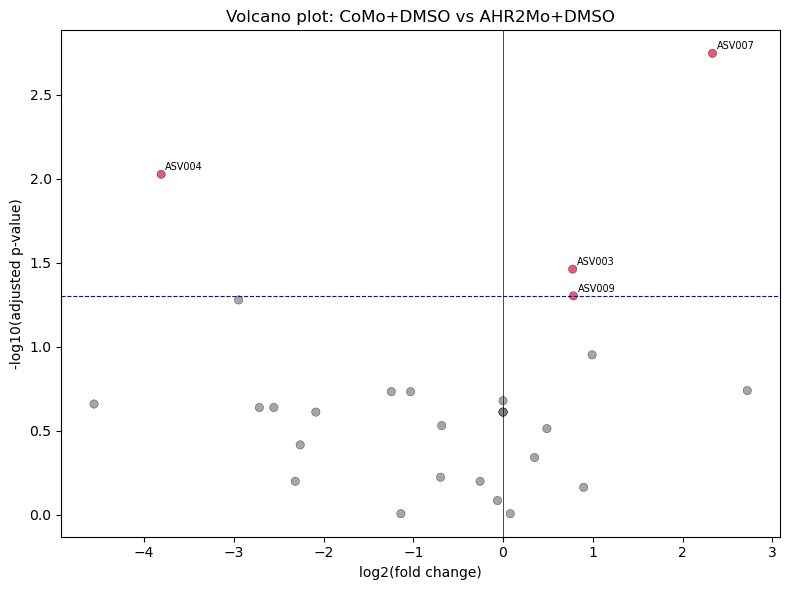

In [76]:
## log2 fold-change to compress values for visual reasons 
kruskal_results['log2_fc'] = kruskal_results['fold_change'].apply(safe_log2)
kruskal_results['neg_log10_p'] = -np.log10(kruskal_results['p_adj']) ## neg also for visual reasons

fig, ax = plt.subplots(figsize=(8, 6))

colors = kruskal_results['significant'].map({True: 'crimson', False: 'grey'})
ax.scatter(kruskal_results['log2_fc'], kruskal_results['neg_log10_p'],
           c=colors, alpha=0.7, edgecolor='k', linewidth=0.3)

# optional: label significant taxa
for _, row in kruskal_results[kruskal_results['significant']].iterrows():
    ax.annotate(row['taxa'], (row['log2_fc'], row['neg_log10_p']),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.axhline(-np.log10(0.05), color='blue', linestyle='--', linewidth=0.8)
ax.axvline(0, color='black', linestyle='-', linewidth=0.5)

ax.set_xlabel('log2(fold change)')
ax.set_ylabel('-log10(adjusted p-value)')
ax.set_title(f'Volcano plot: {str(group1)} vs {str(group2)}')

plt.tight_layout()
plt.show()

What do we think about this figure? Do we think this can be improved at all?

think

* colors

* font size 

* is the main point highlighted and obvious? is this too busy? 

In [77]:
## set up 
import matplotlib as mpl
# generic matplotlib settings
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 11,
    'axes.linewidth': 1.0,
    'axes.edgecolor': 'black',
    'xtick.major.width': 1.0,
    'ytick.major.width': 1.0,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
    'svg.fonttype': 'none',   # keep text as text, not paths, in SVG
    'pdf.fonttype': 42,       # embed fonts properly for Illustrator/editing
})


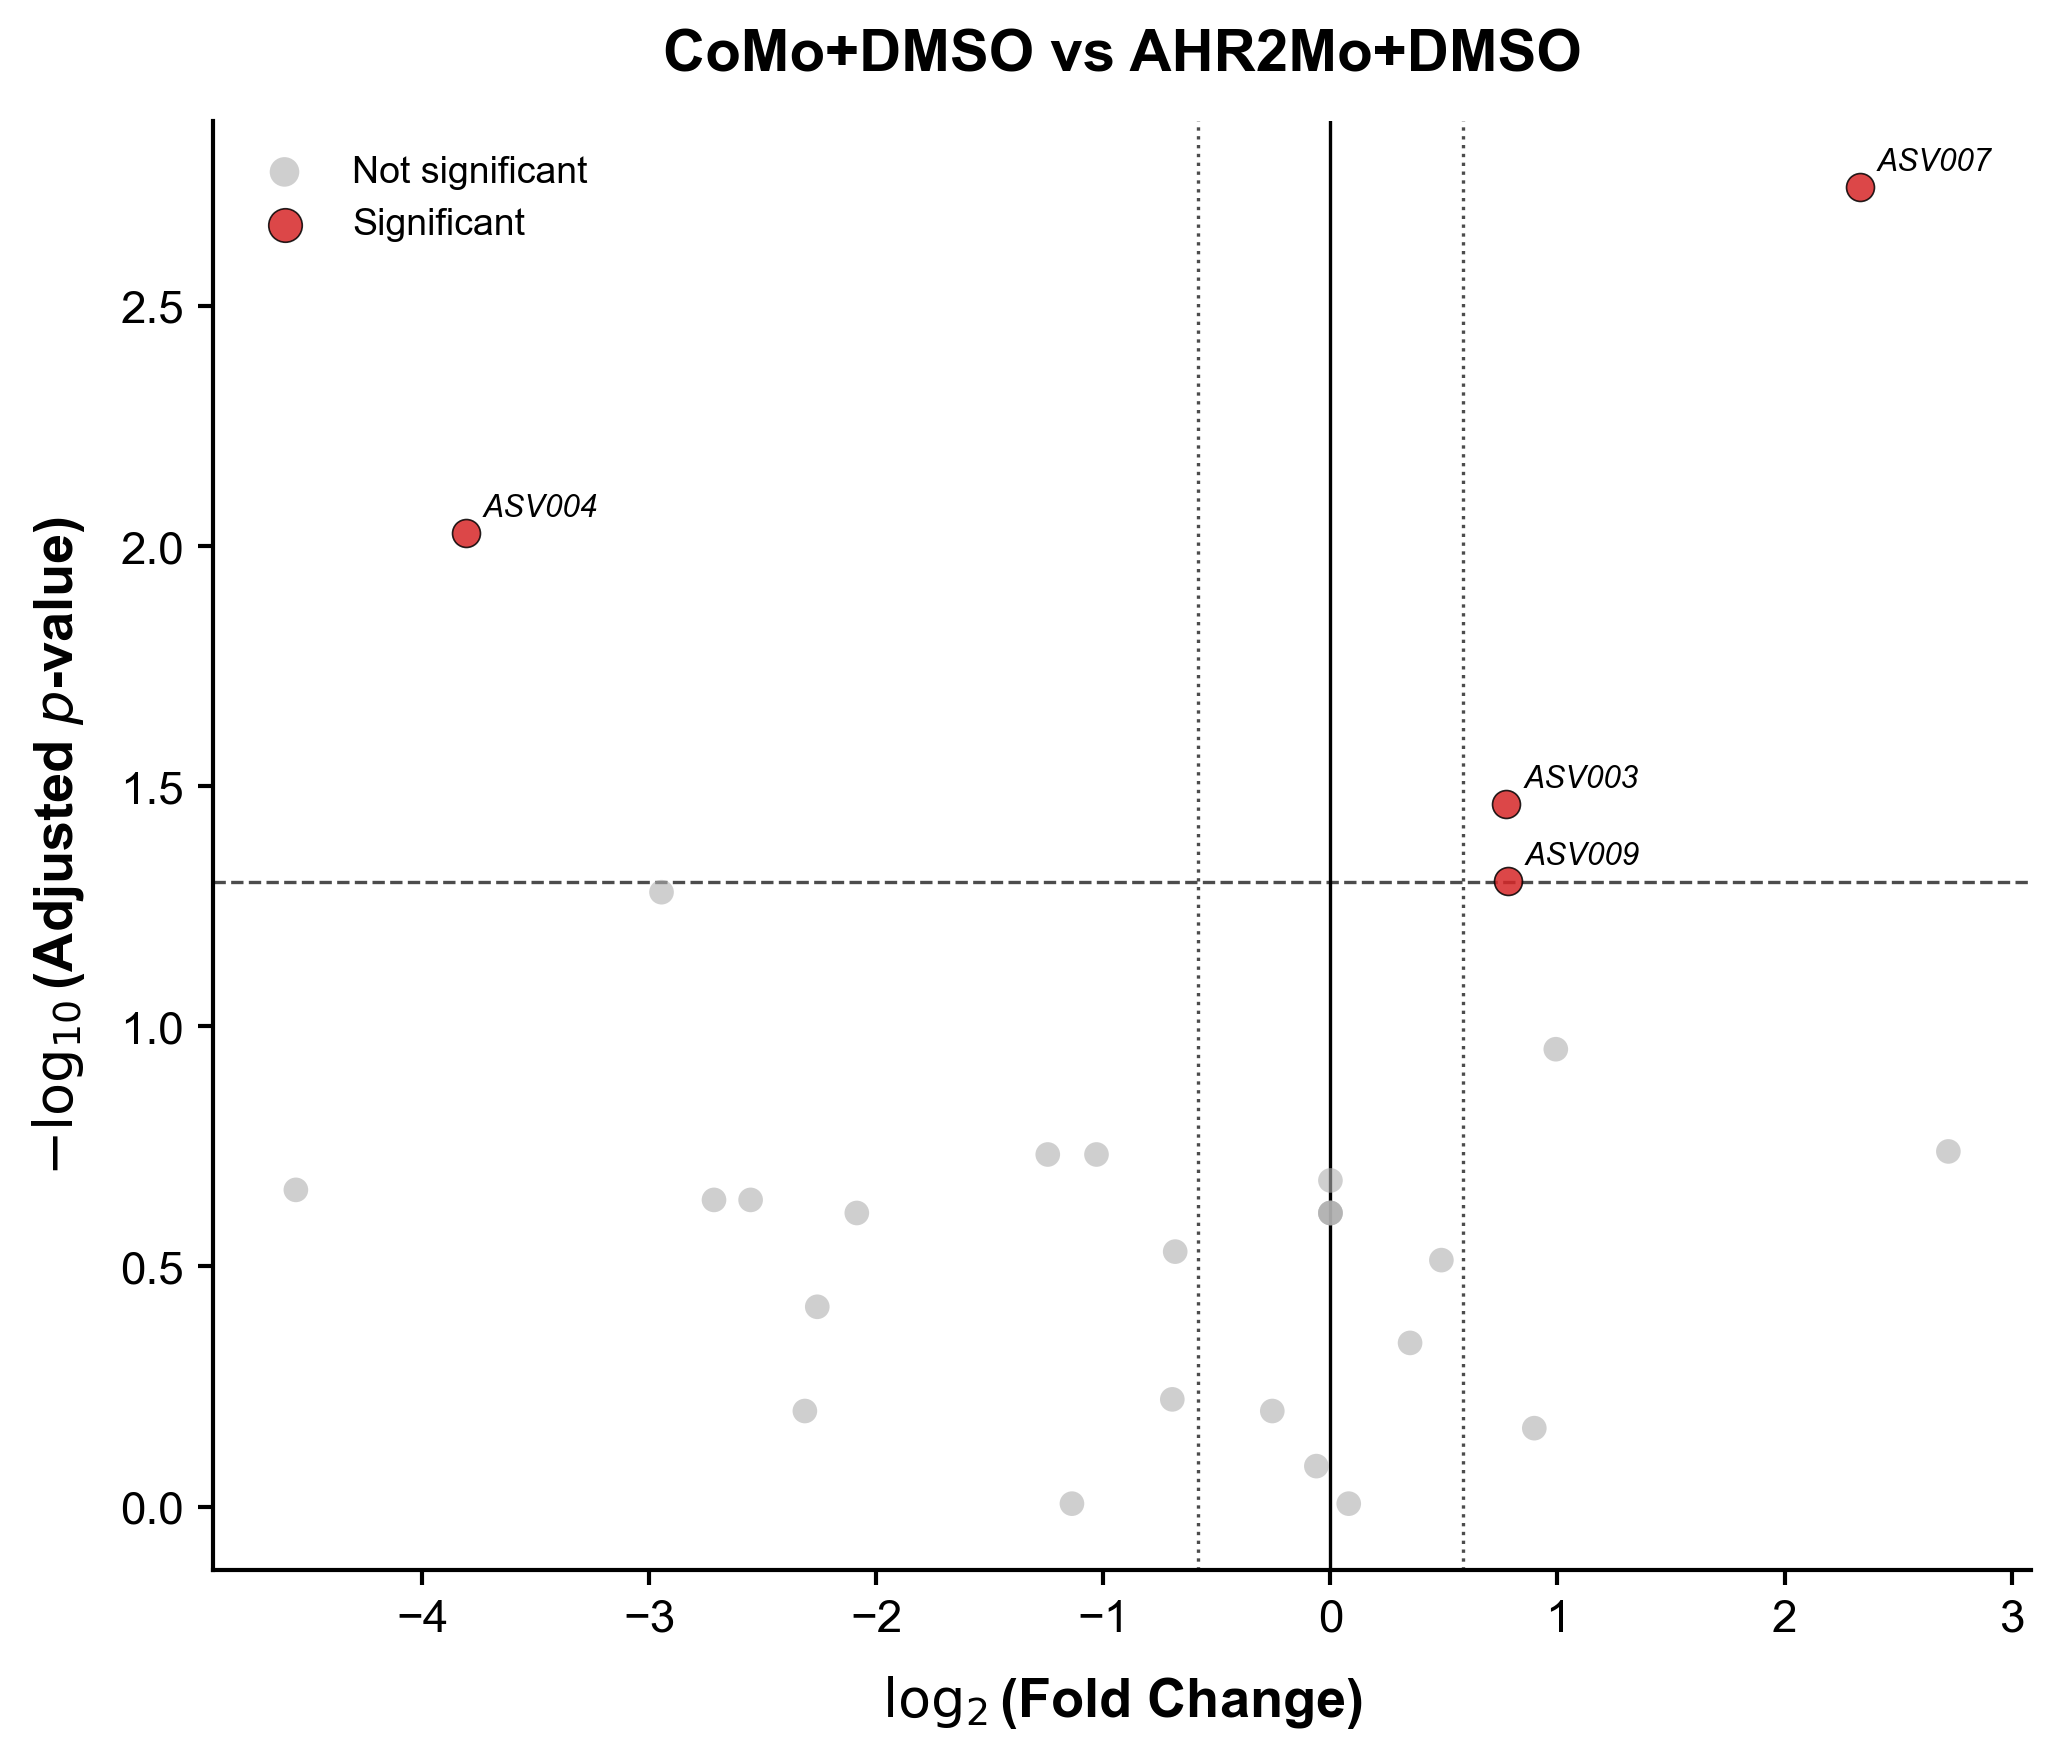

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6), dpi=300)

sig_mask = kruskal_results['significant'].astype(bool) ## yes/no
fc_threshold = 1.5
log2_fc_threshold = np.log2(fc_threshold)  # ≈ 0.585

# non-significant points first (so significant ones sit on top)
ax.scatter(kruskal_results.loc[~sig_mask, 'log2_fc'],
           kruskal_results.loc[~sig_mask, 'neg_log10_p'],
           c='#B0B0B0', alpha=0.6, s=35, edgecolor='none', label='Not significant', zorder=2)

ax.scatter(kruskal_results.loc[sig_mask, 'log2_fc'],
           kruskal_results.loc[sig_mask, 'neg_log10_p'],
           c='#D62728', alpha=0.85, s=45, edgecolor='black', linewidth=0.4,
           label='Significant', zorder=3)

# label significant points, avoiding overlap where possible
texts = []
for _, row in kruskal_results[sig_mask].iterrows():
    texts.append(ax.annotate(row['taxa'], (row['log2_fc'], row['neg_log10_p']),
                fontsize=7.5, fontstyle='italic', xytext=(4, 4),
                textcoords='offset points', zorder=4))

# reference lines
ax.axhline(-np.log10(0.05), color='#4C4C4C', linestyle='--', linewidth=0.8, zorder=1)
ax.axvline(0, color='black', linestyle='-', linewidth=0.8, zorder=1)

ax.axvline(log2_fc_threshold, color='#4C4C4C', linestyle=':', linewidth=0.8, zorder=1)
ax.axvline(-log2_fc_threshold, color='#4C4C4C', linestyle=':', linewidth=0.8, zorder=1)

ax.set_xlabel(r'$\log_2$(Fold Change)', fontsize=13, fontweight='bold', labelpad=8)
ax.set_ylabel(r'$-\log_{10}$(Adjusted $p$-value)', fontsize=13, fontweight='bold', labelpad=8)
ax.set_title(f'{str(group1)} vs {str(group2)}', fontsize=14, fontweight='bold', pad=12)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend(frameon=False, loc='upper left', fontsize=9, markerscale=1.2)

plt.tight_layout()


fname = f"volcano_{str(group1)}_vs_{str(group2)}')"
# save high-res + vector versions
plt.savefig(f'../results/{fname}.png', dpi=600, bbox_inches='tight') ## easiest for powerpoints
plt.savefig(f'../results/{fname}.pdf', bbox_inches='tight')   # best for publication / sharing with collabs
#plt.savefig('../results/{fname}.svg', bbox_inches='tight')   # editable in Illustrator if it needs to be combined w / other images

plt.show()

## Interpretting results

So, what comes next?

First, we can figure out what these specific ASVs are. 

In [ ]:
taxa_dat.loc['ASV004'] ## the ASV label is the index, so we can paste the value directly to loc

Kingdom               Bacteria
Phylum          Proteobacteria
Class      Gammaproteobacteria
Order         Enterobacterales
Family      Enterobacteriaceae
Genus              Plesiomonas
Name: ASV004, dtype: str

Once I see what this taxa is, I can go search on wiki, for example, or Uniprot to see more information about it. 

>> [Wiki](https://en.wikipedia.org/wiki/Plesiomonas_shigelloides)

>> [UniProt](https://www.uniprot.org/taxonomy/703)

>> [ScienceDirect](https://www.sciencedirect.com/topics/agricultural-and-biological-sciences/plesiomonas)

>> [Literature Search](https://scholar.google.com/scholar?hl=en&as_sdt=0%2C5&q=Plesiomonas+zebrafish&btnG=)

#### What if I have many ASVs significant?

It may be easier to merge the entire DF and then search manually afterwards, creating your own excel sheet to save the info: 

In [90]:
## to do this for the whole results table, merge! 

kruskal_w_taxa_names = kruskal_results.merge(taxa_dat, right_index=True, left_on="taxa")
kruskal_w_taxa_names.to_csv("../results/kruskal_results_With_tax_names.csv")
kruskal_w_taxa_names.head()

,taxa,stat,p_value,p_adj,significant,fold_change,log2_fc,neg_log10_p,Kingdom,Phylum,Class,Order,Family,Genus
6,ASV007,15.985802,0.000064,0.001787,True,5.041553,2.333868,2.747890,Bacteria,Proteobacteria,Gammaproteobacteria,Alteromonadales,Shewanellaceae,Shewanella
3,ASV004,11.568223,0.000671,0.009392,True,0.071348,-3.808983,2.027224,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Plesiomonas
2,ASV003,8.429577,0.003692,0.034456,True,1.711756,0.775477,1.462741,Bacteria,Proteobacteria,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
8,ASV009,7.246045,0.007106,0.049740,True,1.720943,0.783199,1.303293,Bacteria,Proteobacteria,Gammaproteobacteria,Vibrionales,Vibrionaceae,Vibrio
11,ASV012,6.747380,0.009389,0.052576,False,0.129749,-2.946205,1.279214,Bacteria,Firmicutes,Bacilli,Erysipelotrichales,Erysipelotrichaceae,ZOR0006
